In [1]:
import random

from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import leastsq
import scipy.stats as stats
import matplotlib
from matplotlib.ticker import FormatStrFormatter
from scipy.optimize import curve_fit
from matplotlib.ticker import ScalarFormatter
import warnings
import copy
from matplotlib.lines import Line2D

pd.options.mode.chained_assignment = None 
# import PCA libraries
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import roc_curve, roc_auc_score

import sys
sys.path.insert(0, '..')

from utils.utils import *

matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
np.random.seed(1)
random.seed(42)

display_names = {'il6':'IL-6','il10':'IL-10','il18':'IL-18','il17':'IL-17','il22':'IL-22','il1b':'IL-1\u03b2','tnfa':'TNF-\u03b1', 'il23':'IL-23'}

figures='../paper_and_outputs/figures/'
data_location = '../measurement_data/'

cancer_cohort_1 = 'IT_cohort_1.xlsx'
cancer_cohort_2 = 'IT_cohort_2.xlsx'

cancer_1_full_path = data_location+cancer_cohort_1
cancer_2_full_path = data_location+cancer_cohort_2

statistical_data_path = '../paper_and_outputs/tables/statistical_data_tables.xlsx'
extended_data_path = '../paper_and_outputs/tables/extended_data_tables.xlsx'
human_svg_path= '../aux_files/man-woman-icon.svg'

dilution_factor = 6
conc_epsilon=0
scale=3.29#

In [2]:
def clean_cals_vals(cals, vals, conc_epsilon=0):
  melted_cals = {}
  calambnames = ['amb1','amb2']
  calmeanpnames = ['meanp1','meanp2']
  calmeannames = ['mean_all1','mean_all2']

  for k, df in cals.items():
    # Average replicates in log space (geometric mean) for calibration curves
    df_avg = df.copy()

    #df_avg['amb'] = np.nan
  
    df_avg['amb'] = stats.gmean(df[calambnames], axis=1, nan_policy='omit')
    df_avg['meanp'] = stats.gmean(df[calmeanpnames],  axis=1,nan_policy='omit')
    df_avg['mean_all'] = stats.gmean(df[calmeannames],  axis=1,nan_policy='omit')

    df_final = df_avg[['conc', 'amb', 'meanp', 'mean_all']].copy()
    melted_cals[k] = df_final
    melted_cals[k]['amb_deviation']=np.std(df[calambnames], axis=1)
    melted_cals[k]['meanp_deviation']=np.std(df[calmeanpnames], axis=1)
    melted_cals[k]['mean_all_deviation']=np.std(df[calmeannames], axis=1)
 

  melted_vals = {}
  for k, df in vals.items():
    # Average replicates in log space (geometric mean) for calibration curves
    df_avg = df.copy()
    
    df_avg['amb'] = np.nan
    df_avg['amb'] = stats.gmean(df[['amb1','amb2']], axis=1, nan_policy='omit')
  
    df_avg['meanp'] = np.nan
    df_avg['meanp'] = stats.gmean(df[['meanp1','meanp2']],  axis=1,nan_policy='omit')

    df_avg['mean_all'] = np.nan
    df_avg['mean_all'] = stats.gmean(df[['mean_all1','mean_all2']],  axis=1,nan_policy='omit')

    df_final = df_avg[['sample','amb', 'meanp', 'mean_all']].copy()
    melted_vals[k] = df_final

  cals = melted_cals
  vals = melted_vals

  for k, df in cals.items():
    cals[k]['conc'] = df['conc'].astype(float)+conc_epsilon
    cals[k]['amb'] = df['amb'].astype(float)
    cals[k]['meanp'] = df['meanp'].astype(float)

  for k, df in vals.items():
    vals[k]['amb'] = df['amb'].astype(float)
    vals[k]['meanp'] = df['meanp'].astype(float)

  return cals, vals

# batch 1

In [3]:
df = pd.read_excel(cancer_1_full_path,header=None)

il6 = df.iloc[:16,0:5]
tnfa = df.iloc[:16,8:13]
il22= df.iloc[:16,16:21]
il23= df.iloc[:16,24:29]


il10 = df.iloc[36:,0:5]
il17 = df.iloc[36:,8:13]
il18 = df.iloc[36:,16:21]

dfs = {'il18':il18,"il17":il17,"il10":il10,"il6":il6,"tnfa":tnfa,"il22":il22,"il23":il23}

cals={}
data={}


cals['il6']=il6.iloc[1:9,:]
cals['il23']=il23.iloc[1:9,:]
cals['il10']=il10.iloc[1:9,:]
cals['il17']=il17.iloc[1:9,:]
cals['tnfa']=tnfa.iloc[1:9,:]
cals['il22']=il22.iloc[1:9,:]
cals['il18']=il18.iloc[1:9,:]


data['il6']=il6.iloc[10:,0:5]
data['il23']=il23.iloc[10:,0:5]
data['il10']=il10.iloc[10:,0:5]
data['il17']=il17.iloc[10:,0:5]
data['tnfa']=tnfa.iloc[10:,0:5]
data['il22']=il22.iloc[10:,0:5]
data['il18']=il18.iloc[10:,0:5]


In [4]:
il10

,0,1,2,3,4
36,IL-10 (pg/mL),AMB,NaN,GeoMean_previous gate,NaN
37,200,0.776529,0.548181,133480,104910.0
38,40,0.345311,0.188742,57805,42015.0
39,8,0.077313,0.048140,39148,28088.0
40,1.6,0.015926,0.011465,31129,26991.0
41,0.32,0.002904,0.002904,23124,24100.0
42,0.064,0.001201,0.002202,18615,10803.0
43,0.0128,0.001501,0.000830,27709,15285.0
44,0,0.00033,0.000450,28261,20541.0
45,NaN,NaN,NaN,NaN,NaN


In [5]:
data['il10']

,0,1,2,3,4
46,IT-1,0.005917,0.017553,33634,31054.0
47,IT-3,0.014809,0.009344,37844,36871.0
48,IT-5,0.001501,0.000750,8386,6502.0
49,IT-7,0.980829,0.923819,203223,250171.0
50,IT-9,0.017757,0.009142,43192,20460.0
51,IT-11,0.001201,0.000690,9371,6145.0


In [6]:
for k,c in cals.items():
  cal_cols=['conc','amb1','amb2','meanp1','meanp2']
  c.columns = cal_cols
  c.reset_index(drop=True,inplace=True)
  for col in cal_cols:
    c[col] = c[col].astype(float)
  for col in cal_cols[1:]:
    c[col] = pd.to_numeric(c[col], errors='coerce')
  cals[k] = c

for k,c in cals.items():

  c['lambda1'] = amb_to_on(c['amb1'])
  c['lambda2'] = amb_to_on(c['amb2'])
  
  c['mean_all1'] =c['lambda1']*c['meanp1']
  c['mean_all2'] =c['lambda2']*c['meanp2']
 
  cals[k] = c

In [7]:
for k,v in data.items():
  v.columns = ['sample','amb1','amb2','meanp1','meanp2']
  v.reset_index(drop=True,inplace=True)
  #v['sample'] = v['sample'].astype(str)
  v.loc[v['amb1'] == 0, 'amb1'] = np.nan
  v.loc[v['amb2'] == 0, 'amb2'] = np.nan
  v['amb1'] = v['amb1'].astype(float)
  v['amb2'] = v['amb2'].astype(float)
  v['meanp1'] = v['meanp1'].astype(float)
  v['meanp2'] = v['meanp2'].astype(float)
  data[k] = v

for k,v in data.items():
  v['amb1'] = pd.to_numeric(v['amb1'], errors='coerce')
  v['amb2'] = pd.to_numeric(v['amb2'], errors='coerce')
  v['meanp1'] = pd.to_numeric(v['meanp1'], errors='coerce')
  v['meanp2'] = pd.to_numeric(v['meanp2'], errors='coerce')
  data[k] = v

for k,v in data.items():
  v['lambda1'] = amb_to_on(v['amb1'])
  v['lambda2'] = amb_to_on(v['amb2'])
  v['mean_all1'] =v['lambda1']*v['meanp1']
  v['mean_all2'] =v['lambda2']*v['meanp2']
  data[k] = v

In [8]:
cals,vals=clean_cals_vals(cals, data, conc_epsilon=conc_epsilon)

In [9]:
#rearange order of cytolines in vals and cals to match display order
order = ['tnfa','il6', 'il10',  'il17','il18', 'il22', 'il23']
cals = {k: cals[k] for k in order}
vals = {k: vals[k] for k in order}

/opt/anaconda3/envs/cocktail/lib/python3.13/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


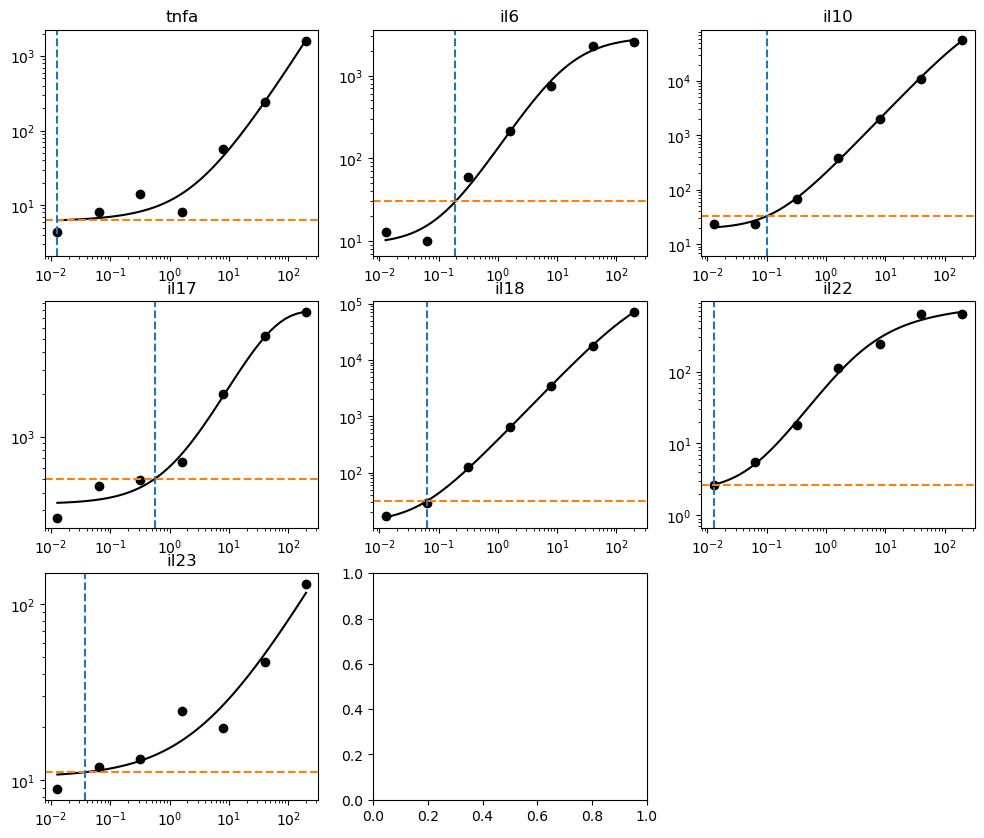

In [10]:
params = {} 
conclimits = {}
measurelimits = {}
llod = {}
llod_conc = {}
llod_conc_ll = {}
ulod = {}
ulod_conc = {}
ulod_conc_ll = {}
xf={}
yf={}
fig, axes = plt.subplots(3, 3, figsize=(12, 10))
axes = axes.flatten()
axes2 = axes.copy()

ambval='mean_all'
ambdev='mean_all_deviation'


for i, (k, df) in enumerate(cals.items()):
  xf[k, ambval], yf[k, ambval], params[k, ambval] = cal_curve_fit(df, x_var='conc', y_var=ambval)

  # Get lowest non-zero concentration
  min_nonzero_conc = min(df[df['conc'] > 0]['conc'])
  amb_at_min_conc = df[df['conc'] == min_nonzero_conc][ambval]

  conclimits[k] = (min_nonzero_conc, max(df['conc']))
  measurelimits[k,ambval] = (min(amb_at_min_conc), max(df[ambval]))

  axes[i].plot(xf[k,ambval],yf[k,ambval], color='k')

  lasymp=df[ambval][7]
  lstandard_deviation=(df[ambdev][7]+df[ambdev][6])/2

  llod_std= lasymp+scale*lstandard_deviation

  llod_lowest_conc=linear_5pl(min_nonzero_conc, *params[k, ambval])
  llod[k] = max(llod_std,llod_lowest_conc)
  
  #loq = lasymp+10*lstandard_deviation
  #loq_conc=invlog5pl(loq, (params[k,'amb'],conclimits[k],amblimits[k]))

  llod_conc[k]=invlog5pl(llod[k], (params[k, ambval],conclimits[k],measurelimits[k, ambval]))
  

  axes[i].axhline(y=llod[k], color='tab:orange', linestyle='--')
  axes[i].axvline(x=llod_conc[k], color='tab:blue', linestyle='--')


  conclimits[k] = (llod_conc[k], conclimits[k][1])
  measurelimits[k, ambval] = (llod[k], measurelimits[k, ambval][1])
  
  axes[i].scatter(df['conc'],df[ambval], color='k')

  axes[i].set_yscale('log')
  #axes2[i].set_yscale('log')
  axes[i].set_xscale('log')
  axes[i].set_title(k)
axes[8].remove()


In [11]:
# save batch 1 cal curve data
cals1=copy.deepcopy(cals)
vals1=copy.deepcopy(vals)
params1=copy.deepcopy(params)
conclimits1=copy.deepcopy(conclimits)
measurelimits1=copy.deepcopy(measurelimits)
llod1=copy.deepcopy(llod)
llod_conc1=copy.deepcopy(llod_conc)
llod_conc_ll1=copy.deepcopy(llod_conc_ll)
xf1=copy.deepcopy(xf)
yf1=copy.deepcopy(yf)


In [12]:
def clean_cals_vals2(cals, vals, conc_epsilon=1e-5):
  melted_cals = {}
  calambnames = ['amb1','amb2', 'amb3','amb4']
  calmeanpnames = ['meanp1','meanp2', 'meanp3','meanp4']
  calmeannames = ['mean_all1','mean_all2', 'mean_all3','mean_all4']
  for k, df in cals.items():
    # Average replicates in log space (geometric mean) for calibration curves
    df_avg = df.copy()

    #df_avg['amb'] = np.nan
  
    df_avg['amb'] = stats.gmean(df[calambnames], axis=1, nan_policy='omit')
 
    df_avg['meanp'] = stats.gmean(df[calmeanpnames],  axis=1,nan_policy='omit')

    df_avg['mean_all'] = stats.gmean(df[calmeannames],  axis=1,nan_policy='omit')
 

    df_final = df_avg[['conc', 'amb', 'meanp',  'mean_all']].copy()
    melted_cals[k] = df_final
    melted_cals[k]['amb_deviation']=np.std(df[calambnames], axis=1)
    melted_cals[k]['meanp_deviation']=np.std(df[calmeanpnames], axis=1)
    melted_cals[k]['mean_all_deviation']=np.std(df[calmeannames], axis=1)
 

  melted_vals = {}
  for k, df in vals.items():
    # Average replicates in log space (geometric mean) for calibration curves
    df_avg = df.copy()
    
    df_avg['amb'] = np.nan
    df_avg['amb'] = stats.gmean(df[['amb1','amb2']], axis=1, nan_policy='omit')

    df_avg['meanp'] = np.nan
    df_avg['meanp'] = stats.gmean(df[['meanp1','meanp2']],  axis=1,nan_policy='omit')

    df_avg['mean_all'] = np.nan
    df_avg['mean_all'] = stats.gmean(df[['mean_all1','mean_all2']],  axis=1,nan_policy='omit')


    df_final = df_avg[['sample','amb', 'meanp',  'mean_all']].copy()
    melted_vals[k] = df_final

  cals = melted_cals
  vals = melted_vals

  for k, df in cals.items():
    cals[k]['conc'] = df['conc'].astype(float)+conc_epsilon
    cals[k]['amb'] = df['amb'].astype(float)
    cals[k]['meanp'] = df['meanp'].astype(float)

  for k, df in vals.items():
    vals[k]['amb'] = df['amb'].astype(float)
    vals[k]['meanp'] = df['meanp'].astype(float)

  return cals, vals

In [13]:
df = pd.read_excel(cancer_2_full_path,header=None) # fn is the filename you uploaded


il6 = df.iloc[1:26,0:10]
tnfa = df.iloc[1:26,11:21]
#il22_old = df.iloc[1:36,22:32]
il23 = df.iloc[1:26,33:43]
il10 = df.iloc[1:26,44:54]
il18 = df.iloc[1:26,55:65]
il17 = df.iloc[1:26,66:76]

il22=df.iloc[38:63,22:32]

cals={}
data={}


cals['il6']=il6.iloc[0:8,1:10]
cals['il23']=il23.iloc[0:8,1:10]
cals['il10']=il10.iloc[0:8,1:10]
cals['il17']=il17.iloc[0:8,1:10]
cals['tnfa']=tnfa.iloc[0:8,1:10]
cals['il22']=il22.iloc[0:8,1:10]
cals['il18']=il18.iloc[0:8,1:10]


data['il6']=il6.iloc[10:,[1,2,3,6,7]]
data['il23']=il23.iloc[10:,[1,2,3,6,7]]
data['il10']=il10.iloc[10:,[1,2,3,6,7]]
data['il17']=il17.iloc[10:,[1,2,3,6,7]]
data['tnfa']=tnfa.iloc[10:,[1,2,3,6,7]]
data['il22']=il22.iloc[10:,[1,2,3,6,7]]
data['il18']=il18.iloc[10:,[1,2,3,6,7]]



In [14]:
il22

,22,23,24,25,26,27,28,29,30,31
38,IL22 (pg/mL),200,3.611918,3.611918,NaN,NaN,145920,114503.0,NaN,NaN
39,NaN,40,2.538307,2.263364,NaN,NaN,26508,25762.0,NaN,NaN
40,NaN,8,0.514165,0.479650,NaN,NaN,11766,11757.0,NaN,NaN
41,NaN,1.6,0.125563,0.105361,NaN,NaN,10707,10425.0,NaN,NaN
42,NaN,0.32,0.034488,0.033350,NaN,NaN,10649,10931.0,NaN,NaN
43,NaN,0.064,0.019897,0.018775,NaN,NaN,9307,10658.0,NaN,NaN
44,NaN,0.0128,0.016841,0.017044,NaN,NaN,10318,10627.0,NaN,NaN
45,NaN,0,0.013389,0.012478,NaN,NaN,10153,9860.0,NaN,NaN
46,NaN,LOD,0.014867,NaN,NaN,NaN,NaN,NaN,NaN,NaN
47,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [15]:
for k,c in cals.items():
  print(k)
  cal_cols=['conc','amb1','amb2','amb3','amb4','meanp1','meanp2','meanp3','meanp4']
  c.columns = cal_cols
  c.reset_index(drop=True,inplace=True)
  for col in cal_cols:
    c[col] = c[col].astype(float)
  for col in cal_cols[1:]:
    c[col] = pd.to_numeric(c[col], errors='coerce')
  cals[k] = c

for k,c in cals.items():
  c['lambda1'] = amb_to_on(c['amb1'])
  c['lambda2'] = amb_to_on(c['amb2'])
  c['lambda3'] = amb_to_on(c['amb3'])
  c['lambda4'] = amb_to_on(c['amb4'])

  c['mean_all1'] =c['lambda1']*c['meanp1']
  c['mean_all2'] =c['lambda2']*c['meanp2']
  c['mean_all3'] =c['lambda3']*c['meanp3']
  c['mean_all4'] =c['lambda4']*c['meanp4']
  cals[k] = c

il6
il23
il10
il17
tnfa
il22
il18


In [16]:
for k,v in data.items():
  v.columns = ['sample','amb1','amb2','meanp1','meanp2']
  v.reset_index(drop=True,inplace=True)
  v['sample'] = v['sample'].astype(str)
  v['amb1'] = v['amb1'].replace(0, np.nan)
  v['amb2'] = v['amb2'].replace(0, np.nan)
  v['amb1'] = v['amb1'].astype(float)
  v['amb2'] = v['amb2'].astype(float)
  v['meanp1'] = v['meanp1'].astype(float)
  v['meanp2'] = v['meanp2'].astype(float)
  data[k] = v

for k,v in data.items():
  v['amb1'] = pd.to_numeric(v['amb1'], errors='coerce')
  v['amb2'] = pd.to_numeric(v['amb2'], errors='coerce')
  v['meanp1'] = pd.to_numeric(v['meanp1'], errors='coerce')
  v['meanp2'] = pd.to_numeric(v['meanp2'], errors='coerce')
  data[k] = v

for k,v in data.items():

  v['lambda1'] = amb_to_on(v['amb1'])
  v['lambda2'] = amb_to_on(v['amb2'])
  v['mean_all1'] =v['lambda1']*v['meanp1']
  v['mean_all2'] =v['lambda2']*v['meanp2']

  data[k] = v

In [17]:
cals, vals =clean_cals_vals2(cals, data, conc_epsilon=conc_epsilon)

In [18]:
#rearange order of cytolines in vals and cals to match display order
order = ['tnfa','il6', 'il10',  'il17','il18', 'il22', 'il23']
cals = {k: cals[k] for k in order}
vals = {k: vals[k] for k in order}

/opt/anaconda3/envs/cocktail/lib/python3.13/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


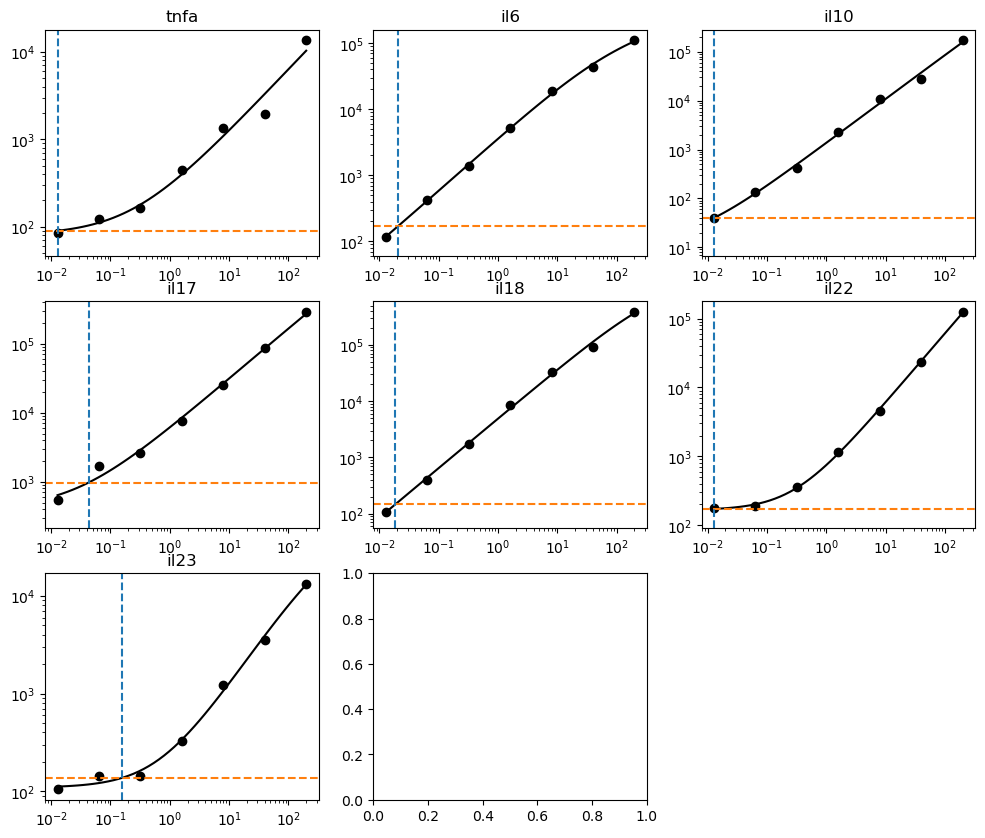

In [19]:
params = {} 
conclimits = {}
measurelimits = {}
llod = {}
llod_conc = {}
llod_conc_ll = {}
ulod = {}
ulod_conc = {}
ulod_conc_ll = {}
xf={}
yf={}
fig, axes = plt.subplots(3, 3, figsize=(12, 10))
axes = axes.flatten()
axes2 = axes.copy()

ambval='mean_all'
ambdev='mean_all_deviation'


for i, (k, df) in enumerate(cals.items()):
  xf[k, ambval], yf[k, ambval], params[k, ambval] = cal_curve_fit(df, x_var='conc', y_var=ambval)

  # Get lowest non-zero concentration
  min_nonzero_conc = min(df[df['conc'] > 0]['conc'])
  amb_at_min_conc = df[df['conc'] == min_nonzero_conc][ambval]

  conclimits[k] = (min_nonzero_conc, max(df['conc']))
  measurelimits[k,ambval] = (min(amb_at_min_conc), max(df[ambval]))

  axes[i].plot(xf[k,ambval],yf[k,ambval], color='k')

  lasymp=df[ambval][7]
  lstandard_deviation=(df[ambdev][7]+df[ambdev][6])/2

  llod_std= lasymp+scale*lstandard_deviation

  llod_lowest_conc=linear_5pl(min_nonzero_conc, *params[k, ambval])
  llod[k] = max(llod_std,llod_lowest_conc)
  
  #loq = lasymp+10*lstandard_deviation
  #loq_conc=invlog5pl(loq, (params[k,'amb'],conclimits[k],amblimits[k]))

  llod_conc[k]=invlog5pl(llod[k], (params[k, ambval],conclimits[k],measurelimits[k, ambval]))
  

  axes[i].axhline(y=llod[k], color='tab:orange', linestyle='--')
  axes[i].axvline(x=llod_conc[k], color='tab:blue', linestyle='--')


  conclimits[k] = (llod_conc[k], conclimits[k][1])
  measurelimits[k, ambval] = (llod[k], measurelimits[k, ambval][1])
  
  axes[i].scatter(df['conc'],df[ambval], color='k')

  axes[i].set_yscale('log')
  #axes2[i].set_yscale('log')
  axes[i].set_xscale('log')
  axes[i].set_title(k)
axes[8].remove()


In [20]:
cals2=copy.deepcopy(cals)
vals2=copy.deepcopy(vals)
params2=copy.deepcopy(params)
conclimits2=copy.deepcopy(conclimits)
measurelimits2=copy.deepcopy(measurelimits)
llod2=copy.deepcopy(llod)
llod_conc2=copy.deepcopy(llod_conc)
llod_conc_ll2=copy.deepcopy(llod_conc_ll)
xf2=copy.deepcopy(xf)
yf2=copy.deepcopy(yf)

In [21]:
cytokine_list = ['tnfa','il6', 'il10',  'il17','il18', 'il22', 'il23']

llod_conc_min={}
for cytokine in cytokine_list:
    llod_conc_min[cytokine] = min(llod_conc1[cytokine], llod_conc2[cytokine])


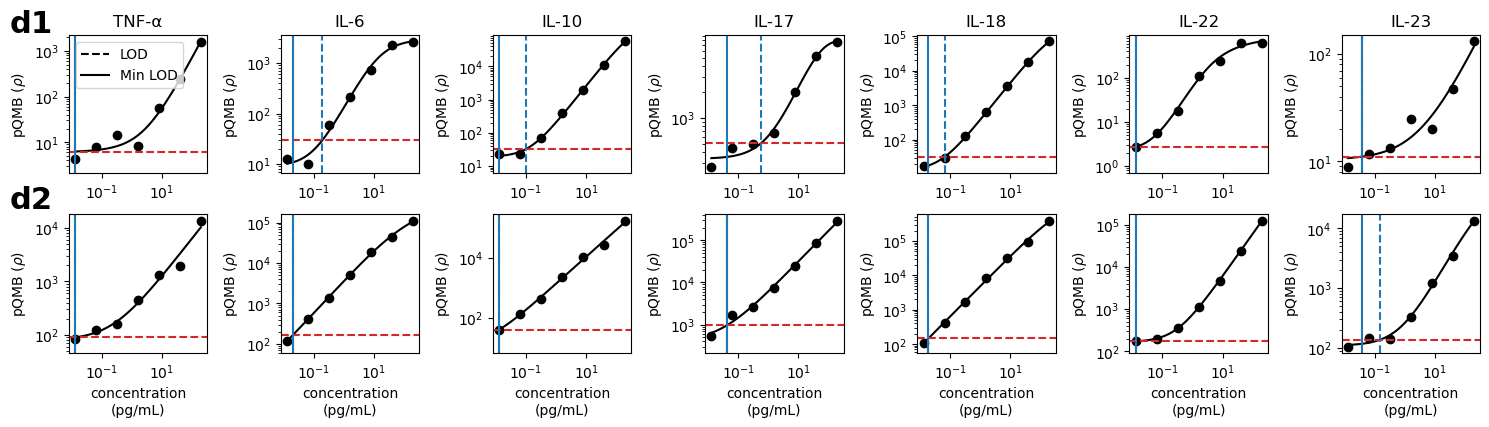

In [22]:
fig, axes = plt.subplots(2, 7, figsize=(15, 4.3))
axes = axes.flatten()
yval='mean_all'
for i, (k, df) in enumerate(cals1.items()):
  axes[i].plot(xf1[k,yval],yf1[k,yval], 'k')
  axes[i].axhline(y=llod1[k], color='tab:red', linestyle='--')
  axes[i].axvline(x= llod_conc1[k], color='tab:blue', linestyle='--')
  axes[i].axvline(x= llod_conc_min[k], color='tab:blue', linestyle='-')


  conclimits1[k] = (llod_conc_min[k], max(df['conc'])) #use min
  
  #llod1[k]=linear_5pl(conclimits1[k][0], *params1[k, ambval])
  #measurelimits1[k, ambval] = (llod1[k], measurelimits1[k, ambval][1])
  #axes[i].axhline(y=llod1[k], color='tab:red', linestyle='-')

 

  axes[i].scatter(df['conc'],df[yval],color='k')
  axes[i].set_yscale('log')
  axes[i].set_xscale('log')
  axes[i].set_title(display_names.get(k))
  #axes[i].set_xlabel('concentration\n(pg/mL)')
  axes[i].set_ylabel(r'pQMB ($\rho$)')
  axes[i].set_box_aspect(1)
#axes[7].remove()
#axes[8].remove()
#plt.tight_layout()
#plt.savefig(output+"cancer_batch_1_cal_curves_batch_correction.pdf")
yval='mean_all'
for i, (k, df) in enumerate(cals2.items()):
  i=i+7
  axes[i].plot(xf2[k,yval],yf2[k,yval], 'k')
  axes[i].axhline(y=llod2[k], color='tab:red', linestyle='--')
  axes[i].axvline(x= llod_conc2[k], color='tab:blue', linestyle='--')
  axes[i].axvline(x= llod_conc_min[k], color='tab:blue', linestyle='-')

  conclimits2[k] = (llod_conc_min[k], max(df['conc'])) #use min
  
  #llod2[k]=linear_5pl(conclimits2[k][0], *params2[k, ambval])
  #measurelimits2[k, ambval] = (llod2[k], measurelimits2[k, ambval][1])
  #axes[i].axhline(y=llod2[k], color='tab:red', linestyle='-')

  axes[i].scatter(df['conc'],df[yval],color= 'k')
  axes[i].set_yscale('log')
  axes[i].set_xscale('log')
  #axes[i].set_title(display_names.get(k))
  axes[i].set_xlabel('concentration\n(pg/mL)')
  axes[i].set_ylabel(r'pQMB ($\rho$)')
  axes[i].set_box_aspect(1)

custom_lines = [Line2D([0], [0], color='k', linestyle='--'), Line2D([0], [0], color='k', linestyle='-')]
axes[0].legend(custom_lines, ['LOD', 'Min LOD'], loc='upper left', fontsize=10)


fig.text(0.01, 0.98, 'd1', fontsize=22, fontweight='bold', va='top', ha='left')
fig.text(0.01, 0.57, 'd2', fontsize=22, fontweight='bold', va='top', ha='left')

#axes[7].remove()
#axes[8].remove()
plt.tight_layout()

plt.savefig(figures+'it_calibration_curves.pdf', bbox_inches='tight')


In [23]:
data={}
vals={}
cals={}
params={}
conclimits={}
amblimits={}
lod={}
lod_conc={}
lod_conc_ll={}
xf={}
yf={}

In [24]:
conclimits1
measurelimits1

{('tnfa', 'mean_all'): (np.float64(6.254642789174893), 1588.4895393170461),
 ('il6', 'mean_all'): (np.float64(29.98178471291269), 2575.6225844242776),
 ('il10', 'mean_all'): (np.float64(33.10399364254424), 56489.749370872574),
 ('il17', 'mean_all'): (np.float64(500.6391734403808), 7688.903349532625),
 ('il18', 'mean_all'): (np.float64(31.971132988352494), 71497.51622659709),
 ('il22', 'mean_all'): (np.float64(2.665220209383506), 638.4991653981075),
 ('il23', 'mean_all'): (np.float64(11.077383900294896), 131.01096193807592)}

In [25]:
for protein, df in vals1.items():
  df['conc']=df['mean_all'].apply(invlog5pl_after_lod, superparams=(params1[protein, 'mean_all'],conclimits1[protein],measurelimits1[protein,'mean_all']))
  df['conc']=df['conc']*dilution_factor

/Users/teg14/Library/CloudStorage/Dropbox/Walt:Gibson lab shared folder/final_paper/v3_github_and_preprint/github_repo/notebooks/../utils/utils.py:64: RuntimeWarning: invalid value encountered in scalar power
  logx = np.log(C) + (1/B) * np.log(((A - D) / (y - D)) ** (1/G) - 1)
/Users/teg14/Library/CloudStorage/Dropbox/Walt:Gibson lab shared folder/final_paper/v3_github_and_preprint/github_repo/notebooks/../utils/utils.py:64: RuntimeWarning: invalid value encountered in log
  logx = np.log(C) + (1/B) * np.log(((A - D) / (y - D)) ** (1/G) - 1)
/Users/teg14/Library/CloudStorage/Dropbox/Walt:Gibson lab shared folder/final_paper/v3_github_and_preprint/github_repo/notebooks/../utils/utils.py:64: RuntimeWarning: invalid value encountered in log
  logx = np.log(C) + (1/B) * np.log(((A - D) / (y - D)) ** (1/G) - 1)
/Users/teg14/Library/CloudStorage/Dropbox/Walt:Gibson lab shared folder/final_paper/v3_github_and_preprint/github_repo/notebooks/../utils/utils.py:64: RuntimeWarning: invalid value 

In [26]:
data1=vals1

In [27]:
vals1['il22']

,sample,amb,meanp,mean_all,conc
0,IT-1,0.000537,9495.445961,5.095791,0.372541
1,IT-3,0.000265,18077.333321,4.796459,0.338512
2,IT-5,0.000960,10253.000000,9.842880,0.879594
3,IT-7,0.000195,7455.175048,1.453281,0.076800
4,IT-9,0.000755,10172.517191,7.680082,0.654203
5,IT-11,0.000225,6760.520098,1.517733,0.076800


In [28]:
for k, df in data1.items():
    df['sample_number'] = df['sample'].str.split('-').str[1].astype(int)
    df['group'] = 'R'
    df.loc[df['sample_number'] >= 13, 'group'] = 'NR'

    df['timepoint'] = 'pre'
    df.loc[df['sample_number'] % 2 == 0, 'timepoint'] = 'post'  # Even sample numbers are "post"


    data1[k] = df

for k, df in data1.items():
    df['subject'] = (df['sample_number'] - 1) // 2 + 1
    #df.loc[df['sample_number'] == 23, 'subject'] = 7  # Assign subject 12 to sample 23
    data1[k] = df

subject_to_patientID = {1:"2690",2:"3137",3:"3032",4:"2907",5:"2409",6:"2132"}
for k,df in data1.items():
    df['patient_id'] = df['subject'].map(subject_to_patientID)

In [29]:
data1['il6']

,sample,amb,meanp,mean_all,conc,sample_number,group,timepoint,subject,patient_id
0,IT-1,0.001132,5960.315260,6.743327,0.122424,1,R,pre,1,2690
1,IT-3,0.000655,7472.015792,4.894028,0.122424,3,R,pre,2,3137
2,IT-5,0.000526,4059.439001,2.136129,0.122424,5,R,pre,3,3032
3,IT-7,0.000339,10248.250875,3.475351,0.122424,7,R,pre,4,2907
4,IT-9,0.001368,11455.358921,15.664968,0.122424,9,R,pre,5,2409
5,IT-11,0.000452,3889.969666,1.756958,0.122424,11,R,pre,6,2132


In [30]:
data_batch1 = copy.deepcopy(data1)

# Batch 2 data table build

In [31]:
sample_to_patient_id = {1:2184,2:1750,3:2877,4:2792,5:2027,6:2472,7:3234,8:350,9:526,10:2538,11:1869,12:2067,13:3335,14:3344,15:3419}

notes = [
    "pre-treatment",
    "pre-treatment",
    "pre-treatment",
    "pre-treatment",
    "pre-treatment",
    "pre-treatment",
    "pre-treatment",
    "pre-treatment",
    "pre-treatment",
    "pre-treatment",
    "pre-treatment",
    "pre-treatment",
    "pre-treatment",
    "pre-treatment",
    "pre-treatment"
]
notes = {i+1:nn for i,nn in enumerate(notes)}

timepoints = [
    "pre",
    "pre",
    "pre",
    "pre",
    "pre",
    "pre",
    "pre",
    "pre",
    "pre",
    "pre",
    "pre",
    "pre",
    "pre",
    "pre",
    "pre"
]

timepoints = {i+1:nn for i,nn in enumerate(timepoints)}

In [32]:
data=vals2

In [33]:
for cytokine in data.keys():
    data[cytokine]['patient_id'] = data[cytokine]['sample'].astype(float).map(sample_to_patient_id)
    data[cytokine]['notes'] = data[cytokine]['sample'].astype(float).map(notes)
    data[cytokine]['timepoint'] = data[cytokine]['sample'].astype(float).map(timepoints)

In [34]:
for protein, df in data.items():
  df['conc']=df['mean_all'].apply(invlog5pl_after_lod, superparams=(params2[protein,'mean_all'],conclimits2[protein],measurelimits2[protein, 'mean_all']))
  df['conc']=df['conc']*dilution_factor
  data[protein] = df

data_full = copy.deepcopy(data)

NRgroup = {1,2,4,5,6,7,8,11,14}
Rgroup = {3,9,10,12,13,15} 
cantsay = {}

for k, df in data.items():
    # df = df[df['sample'] <= 15]
    df['group'] = df['sample'].astype(float).map(lambda x: 'R' if x in Rgroup else ('NR' if x in NRgroup else 'C'))
    data[k] = df

/Users/teg14/Library/CloudStorage/Dropbox/Walt:Gibson lab shared folder/final_paper/v3_github_and_preprint/github_repo/notebooks/../utils/utils.py:64: RuntimeWarning: invalid value encountered in log
  logx = np.log(C) + (1/B) * np.log(((A - D) / (y - D)) ** (1/G) - 1)
/Users/teg14/Library/CloudStorage/Dropbox/Walt:Gibson lab shared folder/final_paper/v3_github_and_preprint/github_repo/notebooks/../utils/utils.py:64: RuntimeWarning: invalid value encountered in log
  logx = np.log(C) + (1/B) * np.log(((A - D) / (y - D)) ** (1/G) - 1)
/Users/teg14/Library/CloudStorage/Dropbox/Walt:Gibson lab shared folder/final_paper/v3_github_and_preprint/github_repo/notebooks/../utils/utils.py:64: RuntimeWarning: invalid value encountered in log
  logx = np.log(C) + (1/B) * np.log(((A - D) / (y - D)) ** (1/G) - 1)
/Users/teg14/Library/CloudStorage/Dropbox/Walt:Gibson lab shared folder/final_paper/v3_github_and_preprint/github_repo/notebooks/../utils/utils.py:64: RuntimeWarning: invalid value encounter

In [35]:
data_batch2 = copy.deepcopy(data)

In [36]:

all_immunotherapy_data = {}
for k,df1 in data_batch1.items():
    df2 = data_batch2[k]
    df1 = df1[['sample','conc','timepoint','patient_id','group']]
    df2 = df2[['sample','conc','timepoint','patient_id','group']]
    # For each dataframe, group by all columns except 'Replicate_Conc.' and calculate mean
    df1_avg = df1.groupby(['sample', 'timepoint', 'patient_id','group'], dropna=False)['conc'].mean().reset_index()
    df2_avg = df2.groupby(['sample', 'timepoint', 'patient_id','group'], dropna=False)['conc'].mean().reset_index()
    df = pd.concat([df1_avg, df2_avg], ignore_index=True)
    df.columns = ["sample","timepoint","patient_id","group","conc"]

    # Concatenate the averaged dataframes
    all_immunotherapy_data[k] = df
  

In [37]:
all_immunotherapy_data['il23']

,sample,timepoint,patient_id,group,conc
0,IT-1,pre,2690,R,16.270140
1,IT-11,pre,2132,R,27.677872
2,IT-3,pre,3137,R,16.231427
3,IT-5,pre,3032,R,0.221484
4,IT-7,pre,2907,R,1.024791
5,IT-9,pre,2409,R,27.186952
6,1,pre,2184,NR,0.221484
7,10,pre,2538,R,6.696435
8,11,pre,1869,NR,0.221484
9,12,pre,2067,R,0.221484


In [38]:
# Create a combined dataframe with all cytokine concentrations
# Each row is a sample, each column is a cytokine
combined_df = pd.DataFrame()

# Get all unique sample IDs across all cytokines
all_samples = set()
for df in all_immunotherapy_data.values():
    if 'sample' in df.columns:
        all_samples.update(df['sample'])
    else:
        all_samples.update(df.index)

# Fill combined dataframe with concentration values
for cytokine, df in all_immunotherapy_data.items():
    if 'sample' in df.columns:
        combined_df[cytokine] = df.set_index('sample')['conc']
    else:
        combined_df[cytokine] = df['conc']

# Calculate z-scores across cytokines for each sample
row_means = np.log(combined_df).mean(axis=1)
row_stds = np.log(combined_df).std(axis=1)
normalized_df = (np.log(combined_df) - row_means.values[:, np.newaxis]) / row_stds.values[:, np.newaxis]

# Add z-scores back to original dataframes
for cytokine, df in all_immunotherapy_data.items():
    if 'sample' in df.columns:
        sample_col = 'sample'
        all_immunotherapy_data[cytokine]['zscore_normalized_value'] = df[sample_col].map(normalized_df[cytokine])
    else:
        all_immunotherapy_data[cytokine]['zscore_normalized_value'] = normalized_df[cytokine].values

# add batch number
for cytokine, df in all_immunotherapy_data.items():
    temp_=all_immunotherapy_data[cytokine]['sample']
    #temp_=map(str, temp_)
    #temp_=temp_.str.startswith('IT')
    #nan_mask = np.isnan(temp_)

# Replace NaN values with False using boolean indexing
    #temp_[nan_mask] = False
    all_immunotherapy_data[cytokine]['batch'] = np.where(temp_.astype(str).str.startswith('IT'), 'batch_1', 'batch_2')

In [39]:

combined_df={}
dfs = []
for cytokine, df in all_immunotherapy_data.items():
    df['cytokine'] = cytokine
    dfs.append(df)
combined_df = pd.concat(dfs, axis=0)

combined_df.reset_index(drop=True,inplace=True)

timepoint_mapping = {'pre': 'pre-ici', 'post': 'post-ici'}
combined_df['timepoint'] = combined_df['timepoint'].replace(timepoint_mapping)

/var/folders/br/3tx211rj6_l8t_1qzgs1m07h0000gp/T/ipykernel_56107/2225649835.py:104: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(new_labels, fontsize=12)


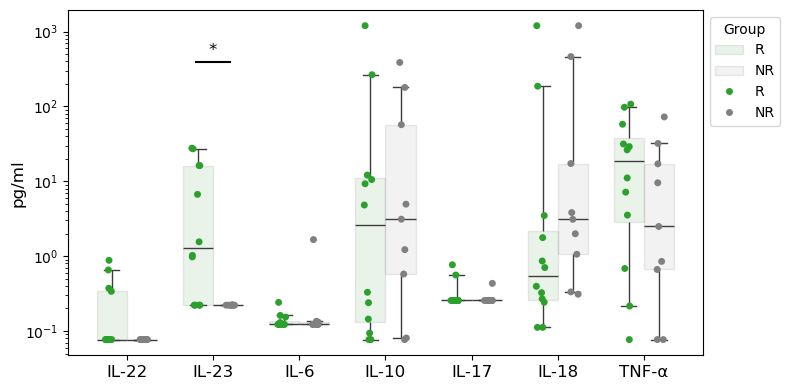

In [40]:
#combined_df=pd.DataFrame
# keep only pre-ici
preici_df=combined_df[combined_df['timepoint'] == 'pre-ici']
# pivot database so that each cytokine is a column with its concentration and the patient id as a row
preici_df=preici_df.pivot(index=['patient_id', 'group'], columns='cytokine', values='conc')
preici_df.columns.name = None
preici_df.reset_index(inplace=True)
preici_df

#reorder cytokines like ibd samples 
preici_df=preici_df[['patient_id', 'group', 'il22', 'il23', 'il6', 'il10', 'il17', 'il18', 'tnfa']]
preici_df



#mannwhitneyu test for each cytokine between R and NR, boxplot with seaborn and * annotation for p-value # also save statisitc to the table with pvalue and corrected pvalue for each cytokine

results=pd.DataFrame()
statistics=pd.DataFrame()
results = {}
statistics = {}
for cytokine in ['il22', 'il23', 'il6', 'il10', 'il17', 'il18', 'tnfa']:
    r_values = preici_df[preici_df['group'] == 'R'][cytokine].dropna()
    nr_values = preici_df[preici_df['group'] == 'NR'][cytokine].dropna()
    stat, p_value = mannwhitneyu(r_values, nr_values)
    results[cytokine] = p_value
    statistics[cytokine] = stat    
results
statistics

# p-values from multiple hypothesis tests
df = pd.DataFrame(results, index=[0])
p_values = df.values.flatten()

# Apply Benjamini-Hochberg correction
reject, pvals_corrected, alphac_sidak, alphac_bonf = multipletests(
    p_values, 
    alpha=0.05, 
    method='fdr_bh')

# add corrected p-values back to results dictionary
corrected_results = {cytokine: pval for cytokine, pval in zip(results.keys(), pvals_corrected)}

# also create table for saving pvalues
results_df = pd.DataFrame({
    'cytokine': list(results.keys()),
    'statisic': list(statistics.values()),
    'p_value': list(results.values()),
    'corrected_p_value': list(pvals_corrected),
})


display_names = {
    'il22': 'IL-22',
    'il23': 'IL-23',
    'il6': 'IL-6',
    'il10': 'IL-10',
    'il17': 'IL-17',
    'il18': 'IL-18',
    'tnfa': 'TNF-α'
}

#convert preici_df from wide to long format
long_df = pd.melt(preici_df, id_vars=['patient_id', 'group'], var_name='cytokine', value_name='conc')   
# Create a boxplot with seaborn and * annotation for p-value
fig, ax = plt.subplots(figsize=(8, 4))
sns.boxplot(data=long_df, x='cytokine', y='conc', hue='group', ax=ax,
            palette=['tab:green', 'gray'], hue_order=['R', 'NR'], width=.7,showfliers=False, zorder=1, boxprops=dict(alpha=.1),whis=[5, 95])
sns.stripplot(data=long_df, x='cytokine', y='conc', hue='group', ax=ax,
              palette=["tab:green", "gray"], hue_order=['R', 'NR'],
              dodge=True, jitter=True, alpha=1, zorder=2)
# Add p-value annotations
y_max = long_df['conc'].max()
y_min = long_df['conc'].min()
y_range = y_max - y_min
for i, cytokine in enumerate(['il22', 'il23', 'il6',    'il10', 'il17', 'il18', 'tnfa']):
    p_value = corrected_results[cytokine]
    if p_value < 0.001:
        annotation = '***'
    elif p_value < 0.01:
        annotation = '**'
    elif p_value < 0.05:
        annotation = '*'
    else:
        annotation = 'ns'
    
    if annotation != 'ns':
        # Determine y position for annotation
        y, h, col = long_df[long_df['cytokine'] == cytokine]['conc'].max() + y_range*0.3, y_range*0.05, 'k'
        ax.plot([i - 0.2, i + 0.2], [y, y], lw=1.5, c=col)
        ax.text(i, y + h, annotation, ha='center', va='bottom', color=col, fontsize=12)


ax.set_yscale('log')
ax.set_ylabel('pg/ml', labelpad=0, fontsize=12)
ax.set_xlabel("")   
# Update x-tick labels with your existing display_names dictionary
current_labels = ax.get_xticklabels()
new_labels = []
for label in current_labels:
    cytokine = label.get_text()
    new_label = display_names.get(cytokine, cytokine)  # Use original if not in dictionary
    new_labels.append(new_label)
ax.set_xticklabels(new_labels, fontsize=12)
ax.legend(title='Group', fontsize=12)
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
fig.tight_layout()
plt.show()




In [41]:
results_df

,cytokine,statisic,p_value,corrected_p_value
0,il22,72.0,0.069704,0.237820
1,il23,90.0,0.003889,0.027222
2,il6,54.0,1.000000,1.000000
3,il10,49.0,0.748804,0.873604
4,il17,58.0,0.682917,0.873604
5,il18,30.5,0.101923,0.237820
6,tnfa,69.0,0.302161,0.528781


In [42]:
preici_df

,patient_id,group,il22,il23,il6,il10,il17,il18,tnfa
0,350,NR,0.076800,0.221484,0.134826,387.177293,0.255835,1200.000000,72.544524
1,526,R,0.076800,0.221484,0.129910,0.329299,0.766707,0.325203,26.320997
2,1750,NR,0.076800,0.221484,0.122424,0.080686,0.255835,1.059577,0.076800
3,1869,NR,0.076800,0.221484,0.122424,3.116739,0.255835,3.824364,0.850519
4,2027,NR,0.076800,0.221484,1.663651,179.639808,0.255835,17.284351,32.035951
5,2067,R,0.076800,0.221484,0.122424,4.818651,0.255835,0.395599,0.215736
6,2184,NR,0.076800,0.221484,0.122424,0.076800,0.255835,0.332974,0.076800
7,2472,NR,0.076800,0.221484,0.122424,4.951894,0.255835,464.033360,17.118313
8,2538,R,0.076800,6.696435,0.241287,0.238810,0.255835,0.242514,31.533260
9,2792,NR,0.076800,0.221484,0.122424,0.577373,0.255835,3.107510,0.663941


In [43]:
# format patient_id as number
preici_df['patient_id'] = preici_df['patient_id'].astype(int)

In [44]:
with pd.ExcelWriter(extended_data_path, mode='a', engine='openpyxl', if_sheet_exists='replace') as writer:  
     preici_df.to_excel(writer, sheet_name='ici_samples_concentrations', index=False)

In [45]:

with pd.ExcelWriter(statistical_data_path, mode='a', engine='openpyxl', if_sheet_exists='replace') as writer:
    results_df.to_excel(writer, sheet_name='it_MWU_tests', index=False)

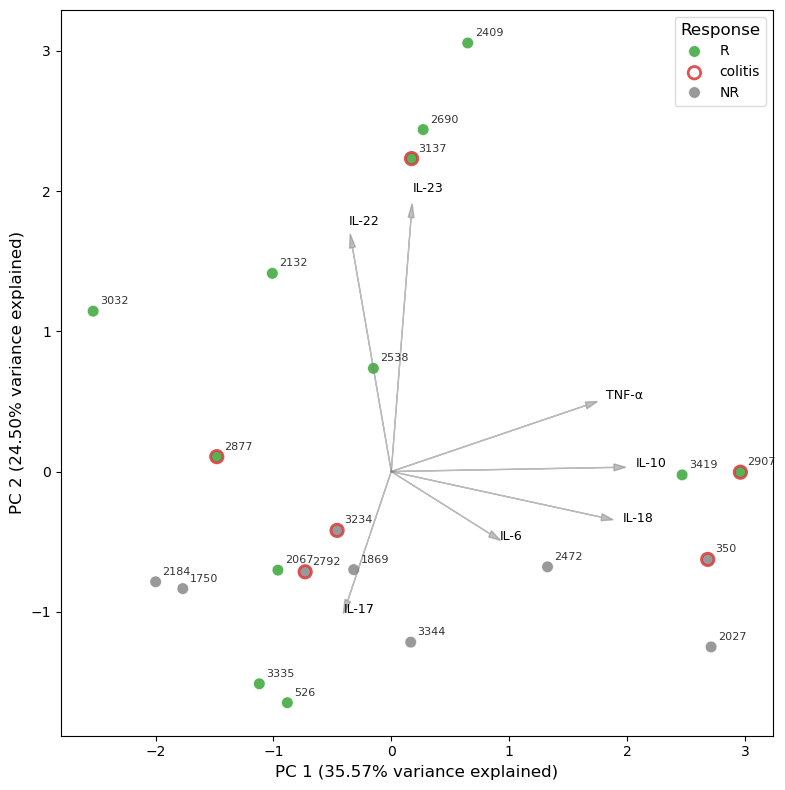

In [46]:
display_names = {
    'il22': 'IL-22',
    'il23': 'IL-23',
    'il6': 'IL-6',
    'il10': 'IL-10',
    'il17': 'IL-17',
    'il18': 'IL-18',
    'tnfa': 'TNF-α'
}
# First, let's create a feature matrix where each column is a cytokine
pre_data = copy.deepcopy(all_immunotherapy_data)
for k,df in pre_data.items():
    # Filter to keep only 'pre' timepoint AND exclude group 'C'
    df = df[(df['timepoint']=='pre') & (df['group'] != 'C')]
    df['patient_id'] = df['patient_id'].astype(str)
    pre_data[k] = df
features = pd.DataFrame()
patient = pd.DataFrame()
raw = pd.DataFrame()
for cytokine, df in pre_data.items():
    features.loc[:,cytokine] = np.log(df['conc'])
    raw[cytokine] = df['conc']
    patient = df['patient_id']



# Get the response groups and sample IDs
groups = pre_data['il6']['group']
#groups = pre_data['il6']['batch']
sample_ids = pre_data['il6']['patient_id']

# Define the color palette - green for Responders, red for Non-Responders
custom_palette = {'R': 'tab:green', 'NR': 'gray'}
#custom_palette = {'batch_1': 'green', 'batch_2': 'red'}


# Perform PCA
pca = PCA(n_components=2)
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)
pca_result = pca.fit_transform(features_scaled)

means = pd.Series(scaler.mean_, index=features.columns) # Means used for normalization
stds = pd.Series(scaler.scale_, index=features.columns) # stds used for normalization

# Create a professional PCA plot
plt.figure(figsize=(8, 8))  # Larger figure for better readability



# Now identify and overplot the special patients with adverse reactions
special_patients = ["2792", "2907","2877","350" ,"3137", "3234"]
special_indices = [i for i, sample_id in enumerate(sample_ids) if sample_id in special_patients]

other_indices = [i for i in range(len(sample_ids)) if i not in special_indices]

# First, plot all points with regular colors
scatter = sns.scatterplot(x=pca_result[:, 0], y=pca_result[:, 1], 
                         hue=groups, 
                         palette=custom_palette, 
                         #style=groups,
                         s=70,  # Larger markers
                         alpha=0.8,  # Slight transparency
                         edgecolor='white',  # White edges for better contrast
                         linewidth=0.5)



lighter_purple = '#8A6CD9'  # Lighter purple
# In the special patients scatter plot:
plt.scatter(pca_result[special_indices, 0], pca_result[special_indices, 1], 
            color='none', s=80, alpha=0.8, edgecolor='tab:red', linewidth=2, 
            marker='o', label='colitis')

# Add sample ID labels with improved formatting
for idx, sample_id in enumerate(sample_ids):
    plt.annotate(sample_id,
                (pca_result[idx, 0], pca_result[idx, 1]),
                xytext=(5, 5),  # Slightly offset
                textcoords='offset points',
                fontsize=8,
                alpha=0.8,
                #bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="none", alpha=0.4)
                )

# Improve the axis labels and title
plt.xlabel(f'PC 1 ({pca.explained_variance_ratio_[0]:.2%} variance explained)', fontsize=12)
plt.ylabel(f'PC 2 ({pca.explained_variance_ratio_[1]:.2%} variance explained)', fontsize=12)
#plt.title('PCA of Pre-Treatment Cytokine Profiles', fontsize=14, fontweight='bold')

arrow_scale = 2  # Scale factor for arrows
text_scale = 2.2  # Scale factor for text
#use display names for cytokines
# add pca loadings

 # use this formula for loadings   loadings_correlated = pca.components_.T * np.sqrt(pca.explained_variance_) and use them in the plot

loadings_correlated = pca.components_.T * np.sqrt(pca.explained_variance_)

for i, cytokine in enumerate(features.columns):
    plt.arrow(0, 0, 
              loadings_correlated.T[0, i]*arrow_scale,  # Scale arrows for visibility
              loadings_correlated.T[1, i]*arrow_scale, 
              color='gray', alpha=0.5, head_width=0.05, head_length=0.1, lw=1)
    plt.text(loadings_correlated.T[0, i]*text_scale, 
             loadings_correlated.T[1, i]*text_scale, 
             display_names[cytokine], color='black', fontsize=9)

handles, labels = plt.gca().get_legend_handles_labels()
r_colitis_idx = labels.index('colitis')
new_order = list(range(len(handles)))
new_order.remove(r_colitis_idx)
new_order.insert(1, r_colitis_idx)  # Put in middle
handles = [handles[i] for i in new_order]
labels = [labels[i] for i in new_order]
legend = plt.legend(handles=handles, labels=labels, title="Response", 
                   title_fontsize=12, fontsize=10, 
                   frameon=True, facecolor='white', edgecolor='lightgray',
                   loc='best')
plt.tight_layout()
plt.savefig(figures+'preici_cytokines_PCA.pdf', bbox_inches='tight')
plt.show()

In [47]:
loadings_correlated

array([[ 0.82645794,  0.23584034],
       [ 0.41914451, -0.22227557],
       [ 0.94436191,  0.01472452],
       [-0.18468557, -0.46019381],
       [ 0.89209436, -0.16305417],
       [-0.16446047,  0.79829703],
       [ 0.08403936,  0.90558797]])

In [48]:
pre_data['il23']

,sample,timepoint,patient_id,group,conc,zscore_normalized_value,batch,cytokine
0,IT-1,pre,2690,R,16.270140,1.017139,batch_1,il23
1,IT-11,pre,2132,R,27.677872,1.619589,batch_1,il23
2,IT-3,pre,3137,R,16.231427,1.157098,batch_1,il23
3,IT-5,pre,3032,R,0.221484,0.309164,batch_1,il23
4,IT-7,pre,2907,R,1.024791,-0.417705,batch_1,il23
5,IT-9,pre,2409,R,27.186952,0.965777,batch_1,il23
6,1,pre,2184,NR,0.221484,0.723335,batch_2,il23
7,10,pre,2538,R,6.696435,1.051951,batch_2,il23
8,11,pre,1869,NR,0.221484,-0.492375,batch_2,il23
9,12,pre,2067,R,0.221484,-0.227717,batch_2,il23


In [49]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
import seaborn as sns
import matplotlib.pyplot as plt
import copy
from sklearn.metrics import roc_auc_score


import numpy as np
from sklearn.datasets import make_classification
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV, LeaveOneOut, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold

# unnormalized features

outlier_patients = {} #["350",'2907', '3419', '2472']
#outlier_index = [i for i, sample_id in enumerate(sample_ids) if sample_id == outlier_patient][0]

# First, let's create a feature matrix where each column is a cytokine
pre_data = copy.deepcopy(all_immunotherapy_data)
for k,df in pre_data.items():
    # Filter to keep only 'pre' timepoint AND exclude group 'C'
    df = df[(df['timepoint']=='pre') & (df['group'] != 'C')]
    df.loc[:,'patient_id'] = df['patient_id'].astype(str)
    pre_data[k] = df


for k,df in pre_data.items():
    # Filter to keep only 'pre' timepoint AND exclude group 'C'
    df = df[(df['patient_id'].isin(outlier_patients)==False)]
    pre_data[k] = df

features = pd.DataFrame()

for cytokine, df in pre_data.items():
    features[cytokine] = df['conc']



# Get the response groups and sample IDs
groups = pre_data['il6']['group']
sample_ids = pre_data['il6']['patient_id']

groups

X=features.to_numpy()
X=np.log(X)


y=groups

le = LabelEncoder()
y = le.fit_transform(y)

cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

# 2. Define the model and hyperparameter grid
# Using a Support Vector Classifier (SVC) as an example
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', LogisticRegression(penalty='l1', solver='liblinear',random_state=42)) 
])


# Parameter grid for the inner loop to find the best hyperparameters
param_grid = {
    'classifier__C': np.logspace(-1, 1, 20)
}

# Initialize LeaveOneOut
loo = LeaveOneOut()

# Store predictions
all_probabilities = []
all_true_labels = []

# Iterate through each fold
for train_index, test_index in loo.split(X):
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]

    # Get class probabilities for the test sample
    inner_grid_search = GridSearchCV(
        estimator=pipeline,
        param_grid=param_grid,
        cv=cv,
        scoring='balanced_accuracy',
        n_jobs=-1
        )

    # Fit the pipeline on the training data
    inner_grid_search.fit(X_train, y_train)
    print(inner_grid_search.best_params_)
    probabilities = inner_grid_search.predict_proba(X_test)[:,1]

    all_probabilities.append(probabilities[0]) # Append the probabilities for the single test sample
    all_true_labels.append(y_test[0]) # Append the true label for the single test sample

out=roc_auc_score(
    all_true_labels,
    all_probabilities
)

print(out)

final_grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=cv, # Can also use a regular k-fold CV here if desired
    scoring='balanced_accuracy',
    n_jobs=-1
)

final_grid_search.fit(X, y)
final_model = final_grid_search.best_estimator_

coef=final_model.named_steps['classifier'].coef_
bias=final_model.named_steps['classifier'].intercept_
print((coef))
print((bias))


{'classifier__C': np.float64(0.42813323987193935)}
{'classifier__C': np.float64(0.42813323987193935)}
{'classifier__C': np.float64(0.42813323987193935)}
{'classifier__C': np.float64(0.33598182862837817)}
{'classifier__C': np.float64(0.42813323987193935)}
{'classifier__C': np.float64(0.42813323987193935)}
{'classifier__C': np.float64(0.42813323987193935)}
{'classifier__C': np.float64(0.42813323987193935)}
{'classifier__C': np.float64(0.42813323987193935)}
{'classifier__C': np.float64(0.33598182862837817)}
{'classifier__C': np.float64(0.33598182862837817)}
{'classifier__C': np.float64(0.42813323987193935)}
{'classifier__C': np.float64(0.5455594781168519)}
{'classifier__C': np.float64(0.42813323987193935)}
{'classifier__C': np.float64(0.5455594781168519)}
{'classifier__C': np.float64(0.42813323987193935)}
{'classifier__C': np.float64(0.42813323987193935)}
{'classifier__C': np.float64(0.42813323987193935)}
{'classifier__C': np.float64(0.42813323987193935)}
{'classifier__C': np.float64(0.42

In [50]:
probabilities_model=all_probabilities

In [51]:
all_probabilities_il23 = np.log(features['il23'])
out=roc_auc_score(
    all_true_labels,
    all_probabilities_il23
)

print(out)

0.8333333333333333


using IL-23 alone you get an AUC of 0.833

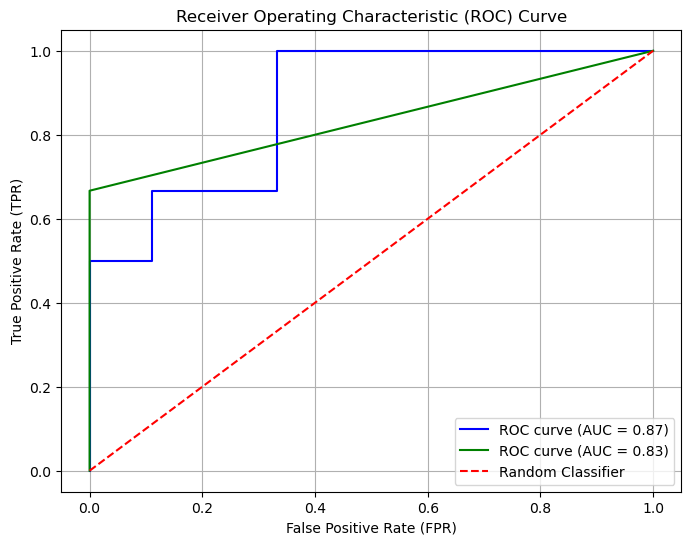

In [52]:

# 4. Calculate FPR, TPR, and thresholds
fpr_model, tpr_model, _ = roc_curve(all_true_labels, probabilities_model)
fpr_il23, tpr_il23, _ = roc_curve(all_true_labels, all_probabilities_il23)

# 5. Calculate AUC score
auc_score_model = roc_auc_score(all_true_labels, probabilities_model)
auc_score_il23 = roc_auc_score(all_true_labels, all_probabilities_il23)

# 6. Plot the ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr_model, tpr_model, color='blue', label=f'ROC curve (AUC = {auc_score_model:.2f})')
plt.plot(fpr_il23, tpr_il23, color='green', label=f'ROC curve (AUC = {auc_score_il23:.2f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--', label='Random Classifier') # Baseline
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend()
plt.grid(True)
plt.show()

In [53]:
import numpy as np
from sklearn.metrics import roc_auc_score

def bootstrap_auc_ci(y_true, p_hat, B=10000, seed=0, stratified=True):
    """
    Bootstrap CI for AUC using patient-level resampling of (y_true, p_hat).

    Parameters
    ----------
    y_true : array-like, shape (n,)
        True binary labels (0/1)
    p_hat : array-like, shape (n,)
        Out-of-sample predicted probabilities from outer CV
    B : int
        Number of bootstrap replicates
    seed : int
        RNG seed
    stratified : bool
        If True, do class-stratified bootstrap (recommended for small n)

    Returns
    -------
    auc_point : float
        AUC on full data (pooled CV predictions)
    ci_95 : tuple(float, float)
        2.5th and 97.5th percentile CI
    auc_boot : np.ndarray
        Bootstrap AUC values, shape (B,)
    """
    y_true = np.asarray(y_true).astype(int)
    p_hat = np.asarray(p_hat).astype(float)

    auc_point = roc_auc_score(y_true, p_hat)
    rng = np.random.default_rng(seed)

    n = len(y_true)
    idx_all = np.arange(n)

    if stratified:
        idxR = idx_all[y_true == 1]
        idxN = idx_all[y_true == 0]
        nR, nN = len(idxR), len(idxN)

    auc_boot = np.empty(B, dtype=float)
    k = 0

    while k < B:
        if stratified:
            sampR = rng.choice(idxR, size=nR, replace=True)
            sampN = rng.choice(idxN, size=nN, replace=True)
            idx = np.concatenate([sampR, sampN])
        else:
            idx = rng.choice(idx_all, size=n, replace=True)

        # AUC needs both classes present:
        if len(np.unique(y_true[idx])) < 2:
            continue

        auc_boot[k] = roc_auc_score(y_true[idx], p_hat[idx])
        k += 1

    lo, hi = np.percentile(auc_boot, [2.5, 97.5])
    return auc_point, (lo, hi), auc_boot


def bootstrap_auc_delta_ci(y_true, p1, p2, B=10000, seed=0, stratified=True):
    """
    Bootstrap CI for difference in AUC: AUC(p1) - AUC(p2).
    Resamples patients and recomputes both AUCs on the same resample.
    """
    y_true = np.asarray(y_true).astype(int)
    p1 = np.asarray(p1).astype(float)
    p2 = np.asarray(p2).astype(float)

    auc1 = roc_auc_score(y_true, p1)
    auc2 = roc_auc_score(y_true, p2)
    delta_point = auc1 - auc2

    rng = np.random.default_rng(seed)
    n = len(y_true)
    idx_all = np.arange(n)

    if stratified:
        idxR = idx_all[y_true == 1]
        idxN = idx_all[y_true == 0]
        nR, nN = len(idxR), len(idxN)

    delta_boot = np.empty(B, dtype=float)
    k = 0

    while k < B:
        if stratified:
            sampR = rng.choice(idxR, size=nR, replace=True)
            sampN = rng.choice(idxN, size=nN, replace=True)
            idx = np.concatenate([sampR, sampN])
        else:
            idx = rng.choice(idx_all, size=n, replace=True)

        if len(np.unique(y_true[idx])) < 2:
            continue

        auc1_b = roc_auc_score(y_true[idx], p1[idx])
        auc2_b = roc_auc_score(y_true[idx], p2[idx])
        delta_boot[k] = auc1_b - auc2_b
        k += 1

    lo, hi = np.percentile(delta_boot, [2.5, 97.5])
    return delta_point, (lo, hi), delta_boot


In [54]:
full_model_ = bootstrap_auc_ci(p_hat=all_probabilities, y_true=all_true_labels)

In [55]:
raw_ = bootstrap_auc_ci(p_hat=all_probabilities_il23, y_true=all_true_labels)

In [56]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

def stratified_bootstrap_indices(y, rng):
    y = np.asarray(y).astype(int)
    idx = np.arange(len(y))
    idxR = idx[y == 1]
    idxN = idx[y == 0]
    sampR = rng.choice(idxR, size=len(idxR), replace=True)
    sampN = rng.choice(idxN, size=len(idxN), replace=True)
    return np.concatenate([sampR, sampN])

def roc_with_bootstrap_band(y_true, p_hat, B=10000, seed=0, grid_size=200):
    """
    Compute pooled ROC + bootstrap ROC band from (y_true, p_hat).
    Assumes p_hat are out-of-sample probabilities (e.g., nested LOOCV outer predictions).
    """
    y_true = np.asarray(y_true).astype(int)
    p_hat = np.asarray(p_hat).astype(float)

    # Point estimate ROC + AUC
    fpr, tpr, _ = roc_curve(y_true, p_hat)
    auc_point = roc_auc_score(y_true, p_hat)

    # Fixed FPR grid for interpolation
    fpr_grid = np.linspace(0, 1, grid_size)
    tpr_boot = np.zeros((B, grid_size), dtype=float)
    auc_boot = np.zeros(B, dtype=float)

    rng = np.random.default_rng(seed)

    k = 0
    while k < B:
        idx_bs = stratified_bootstrap_indices(y_true, rng)

        # Need both classes
        if len(np.unique(y_true[idx_bs])) < 2:
            continue

        fpr_b, tpr_b, _ = roc_curve(y_true[idx_bs], p_hat[idx_bs])
        auc_boot[k] = roc_auc_score(y_true[idx_bs], p_hat[idx_bs])

        # Interpolate TPR onto common grid
        # Ensure fpr_b starts at 0 and ends at 1 for interpolation stability
        tpr_interp = np.interp(fpr_grid, fpr_b, tpr_b)
        tpr_interp[0] = 0.0
        tpr_interp[-1] = 1.0
        tpr_boot[k, :] = tpr_interp

        k += 1

    # Bands
    tpr_med = np.median(tpr_boot, axis=0)
    tpr_lo = np.percentile(tpr_boot, 2.5, axis=0)
    tpr_hi = np.percentile(tpr_boot, 97.5, axis=0)

    auc_lo, auc_hi = np.percentile(auc_boot, [2.5, 97.5])

    return {
        "fpr": fpr,
        "tpr": tpr,
        "auc": auc_point,
        "auc_ci": (auc_lo, auc_hi),
        "fpr_grid": fpr_grid,
        "tpr_med": tpr_med,
        "tpr_lo": tpr_lo,
        "tpr_hi": tpr_hi,
        "auc_boot": auc_boot,
    }

def plot_roc_with_band(results, label="Model", ax=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(5, 4))

    fpr = results["fpr"]
    tpr = results["tpr"]
    auc = results["auc"]
    auc_lo, auc_hi = results["auc_ci"]
    fpr_grid = results["fpr_grid"]
    tpr_lo = results["tpr_lo"]
    tpr_hi = results["tpr_hi"]

    # Main ROC curve
    ax.plot(fpr, tpr, linewidth=2,
            label=f"{label} (AUC={auc:.2f}, 95% CI {auc_lo:.2f}-{auc_hi:.2f})")

    # Bootstrap band
    ax.fill_between(fpr_grid, tpr_lo, tpr_hi, alpha=0.2, linewidth=0)

    # Diagonal
    ax.plot([0, 1], [0, 1], linestyle="--", linewidth=1)

    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.legend(loc="lower right", frameon=True)
    return ax

# add median value of bootstrap in addition to auc-point to the histogram, add auc-point to the legend as well
# add 95% interval values to legend as well


def plot_auc_bootstrap_hist(auc_boot, auc_point=None, ax=None, bins=30):
    if ax is None:
        fig, ax = plt.subplots(figsize=(4, 3))

    ax.hist(auc_boot, bins=bins, alpha=0.7)
    if auc_point is not None:
        ax.axvline(auc_point, color='k', linestyle='-', linewidth=2, label=f"AUC={auc_point:.2f}")
    ax.set_xlabel("Bootstrap AUC")
    ax.set_ylabel("Count")
    if auc_point is not None:
        auc_median = np.median(auc_boot)
        ax.axvline(auc_median, color='green', linestyle='-.', linewidth=2, label=f"Median boot AUC={auc_median:.2f}")
        auc_lo, auc_hi = np.percentile(auc_boot, [2.5, 97.5])
        ax.axvline(auc_lo, color='r', linestyle=':', linewidth=2,  label=f"95% CI [{auc_lo:.2f}, {auc_hi:.2f}]")
        ax.axvline(auc_hi, color='r', linestyle=':', linewidth=2)
        ax.legend(fontsize=8)
    return ax


In [57]:
res_model = roc_with_bootstrap_band(all_true_labels, all_probabilities, B=1000, seed=1)
res_il23  = roc_with_bootstrap_band(all_true_labels, all_probabilities_il23,  B=1000, seed=2)



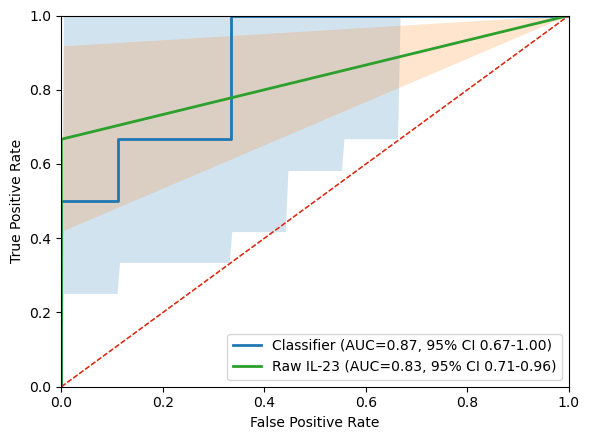

In [58]:

fig, ax = plt.subplots(figsize=(6, 4.5))
plot_roc_with_band(res_model, label="Classifier", ax=ax)
plot_roc_with_band(res_il23,  label="Raw IL-23", ax=ax)
plt.tight_layout()
plt.show()

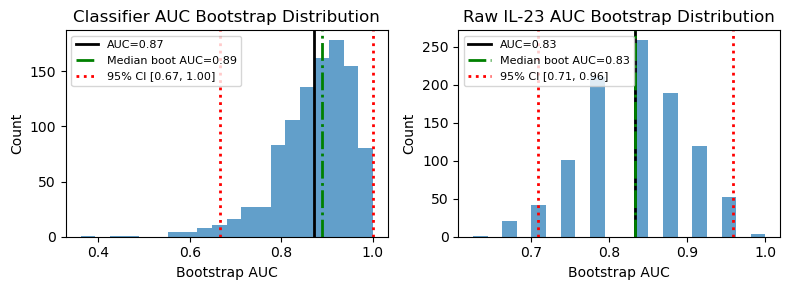

In [59]:
# create subplots for AUC bootstrap distributions for both model and raw IL-23
fig, axes = plt.subplots(1, 2, figsize=(8, 3))
plot_auc_bootstrap_hist(res_model["auc_boot"], auc_point=res_model["auc"], ax=axes[0], bins=20)
axes[0].set_title("Classifier AUC Bootstrap Distribution")
plot_auc_bootstrap_hist(res_il23["auc_boot"], auc_point=res_il23["auc"], ax=axes[1], bins=20)
axes[1].set_title("Raw IL-23 AUC Bootstrap Distribution")
plt.tight_layout()

plt.savefig(figures+'ici_bootstrap_histogram.pdf', bbox_inches='tight')
plt.show()

/var/folders/br/3tx211rj6_l8t_1qzgs1m07h0000gp/T/ipykernel_56107/2624262293.py:59: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(new_labels)


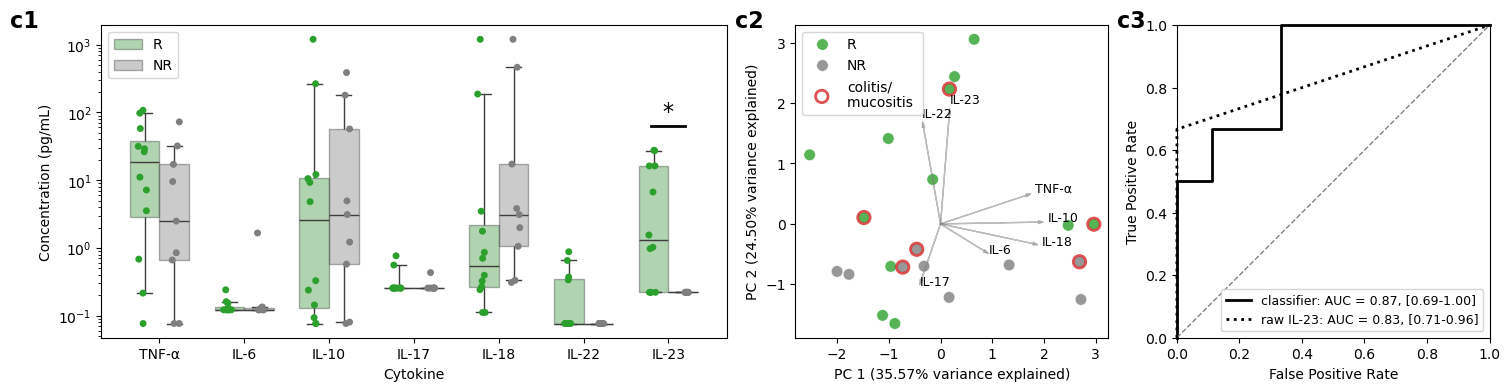

In [60]:
# this plot will copy the style of the ibd combined plot boxplots with points in A, PCA in B and AUROC in C

mosaic = """
AABC
"""
fig, ax_dict = plt.subplot_mosaic(mosaic,figsize=(15, 6), layout='constrained')



ax=ax_dict['A']

#convert preici_df from wide to long format
long_df = pd.melt(preici_df, id_vars=['patient_id', 'group'], var_name='cytokine', value_name='conc')   
# Create a boxplot with seaborn and * annotation for p-value
sns.boxplot(data=long_df, x='cytokine', y='conc', hue='group', ax=ax,
            palette=['tab:green', 'tab:gray'], hue_order=['R', 'NR'], width=.7,showfliers=False, zorder=1, boxprops=dict(alpha=.4),whis=[5, 95], order=['tnfa','il6', 'il10', 'il17', 'il18','il22', 'il23'])
sns.stripplot(data=long_df, x='cytokine', y='conc', hue='group', ax=ax,
              palette=["tab:green", "tab:gray"], hue_order=['R', 'NR'],
              dodge=True, jitter=True, alpha=1, zorder=2, order=['tnfa','il6', 'il10', 'il17', 'il18','il22', 'il23'])

ax.legend_.remove()
# Get existing legend and add significance legend
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[0:2] , labels[0:2], loc='upper left')

# Add p-value annotations
y_max = long_df['conc'].max()
y_min = long_df['conc'].min()
y_range = (y_max - y_min)/10
for i, cytokine in enumerate([ 'tnfa','il6', 'il10', 'il17', 'il18','il22', 'il23' ]):
    p_value = corrected_results[cytokine]
    if p_value < 0.001:
        annotation = '***'
    elif p_value < 0.01:
        annotation = '**'
    elif p_value < 0.05:
        annotation = '*'
    else:
        annotation = 'ns'
    
    if annotation != 'ns':
        # Determine y position for annotation
        y, h, col = long_df[long_df['cytokine'] == cytokine]['conc'].max() + y_range*0.3, y_range*0.05, 'k'
        ax.plot([i - 0.2, i + 0.2], [y, y], lw=2, c=col)
        ax.text(i, y + h, annotation, ha='center', va='bottom', color=col, fontsize=16)


ax.set_yscale('log')
ax.set_ylabel('Concentration (pg/mL)')
ax.set_xlabel('Cytokine')

# Update x-tick labels with your existing display_names dictionary
current_labels = ax.get_xticklabels()
new_labels = []
for label in current_labels:
    cytokine = label.get_text()
    new_label = display_names.get(cytokine, cytokine)  # Use original if not in dictionary
    new_labels.append(new_label)
ax.set_xticklabels(new_labels)

ax.set_box_aspect(0.5)

ax=ax_dict['B']

# use tab:red and tab:gray for R and NR
custom_palette = {'R': 'tab:green', 'NR': 'tab:gray'}
scatter = sns.scatterplot(ax=ax,x=pca_result[:, 0], y=pca_result[:, 1], 
                         hue=groups, 
                         palette=custom_palette, 
                         #style=groups,
                         s=70,  # Larger markers
                         alpha=0.8,  # Slight transparency
                         edgecolor='white',  # White edges for better contrast
                         linewidth=0.5)


colitis_color= 'tab:red' 
# In the special patients scatter plot:
ax.scatter(pca_result[special_indices, 0], pca_result[special_indices, 1], 
            color='none', s=80, alpha=0.8, edgecolor=colitis_color, linewidth=2, 
            marker='o', label='colitis/\nmucositis ')

ax.set_box_aspect(1)
ax.set_xlabel(f'PC 1 ({pca.explained_variance_ratio_[0]:.2%} variance explained)')
ax.set_ylabel(f'PC 2 ({pca.explained_variance_ratio_[1]:.2%} variance explained)')
#sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))


for i, cytokine in enumerate(features.columns):
    ax.arrow(0, 0, 
              loadings_correlated.T[0, i]*arrow_scale,  # Scale arrows for visibility
              loadings_correlated.T[1, i]*arrow_scale, 
              color='gray', alpha=0.5, head_width=0.05, head_length=0.1, lw=1)
    ax.text(loadings_correlated.T[0, i]*text_scale, 
             loadings_correlated.T[1, i]*text_scale, 
             display_names[cytokine], color='black', fontsize=9)


ax.legend_.remove()
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[0:3] , labels[0:3], loc='upper left')

ax=ax_dict['C']

ax.plot(fpr_model, tpr_model, color='black', linestyle='-',lw=2, label=f'classifier: AUC = {auc_score_model:.2f}, [{full_model_[1][0]:.2f}-{full_model_[1][1]:.2f}]')
ax.plot(fpr_il23, tpr_il23, color='black', linestyle=':', lw=2, label=f'raw IL-23: AUC = {auc_score_il23:.2f}, [{raw_[1][0]:.2f}-{raw_[1][1]:.2f}]')
ax.set_box_aspect(1)
for artist in ax.get_children():
    artist.set_clip_on(False)

ax.plot([0, 1], [0, 1],"--", color='gray', lw=1)
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.0])
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_box_aspect(1.0)
ax.legend(fontsize=9, loc='lower right')

subplot_labels = ['c1', 'c2', 'c3']
for ax, label in zip(ax_dict.values(), subplot_labels):
    ax.text(-0.1, 1.05, label, transform=ax.transAxes,
            fontsize=16, fontweight='bold', va='top', ha='right')

plt.show()

In [61]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.transforms as transforms
import re
from svgpathtools import svg2paths
from svgpath2mpl import parse_path
import matplotlib.path as mpath # Import matplotlib.path
import numpy as np # Import numpy for numerical operations

def extract_color(attr_dict):
    """
    Helper function to find the color of a path.
    SVGs store colors either in a 'fill' attribute or inside a 'style' string.
    """
    # 1. Check direct fill attribute
    if 'fill' in attr_dict and attr_dict['fill'] != 'none':
        return attr_dict['fill']

    # 2. Check inside the style attribute (e.g., style="fill:#FFFFFF;")
    if 'style' in attr_dict:
        match = re.search(r'fill:\s*([^;]+)', attr_dict['style'])
        if match and match.group(1) != 'none':
            return match.group(1)

    # Default to a dark grey if no fill is found (helpful for outlines)
    return "#333333"
"#070505"
def place_svg_on_ax(ax, svg_filepath, x_data_center, y_data_center, desired_width_in_data_units):
    """
    Places an SVG vector graphic on a Matplotlib Axes object, preserving its aspect ratio
    even if the axes' data aspect ratio is not equal.

    Args:
        ax (matplotlib.axes.Axes): The Matplotlib axes to draw on.
        svg_filepath (str): The path to the SVG file.
        x_data_center (float): The x-coordinate (in data units) for the center of the SVG.
        y_data_center (float): The y-coordinate (in data units) for the center of the SVG.
        desired_width_in_data_units (float): The desired width of the SVG in axes' data units.
    """
    paths, attributes = svg2paths(svg_filepath)

    # Calculate overall bounding box to normalize scaling
    min_x, max_x, min_y, max_y = float('inf'), float('-inf'), float('inf'), float('-inf')
    for path in paths:
        if path.bbox() is not None:
            px_min_x, px_max_x, px_min_y, px_max_y = path.bbox()
            min_x = min(min_x, px_min_x)
            max_x = max(max_x, px_max_x)
            min_y = min(min_y, px_min_y)
            max_y = max(max_y, px_max_y)

    svg_width = max_x - min_x
    svg_height = max_y - min_y

    # Calculate the base scale for x, based on desired width in data units
    base_scale_factor = desired_width_in_data_units / svg_width

    # Get the transformation matrix from data coordinates to display coordinates
    trans_data_matrix = ax.transData.get_matrix()

    # Calculate the effective scaling factors for x and y in display coordinates
    # These are the lengths of the unit vectors of the data coordinate system in display space
    scale_x_in_display = np.sqrt(trans_data_matrix[0,0]**2 + trans_data_matrix[1,0]**2)
    scale_y_in_display = np.sqrt(trans_data_matrix[0,1]**2 + trans_data_matrix[1,1]**2)

    # Calculate the compensation factor needed to maintain aspect ratio on screen
    # If scale_y_in_display is greater than scale_x_in_display, it means y-units are stretched,
    # so we need to compress our y-scaling to counteract it.
    # If scale_x_in_display is greater, y-units are compressed, so we need to expand y-scaling.
    compensation_factor = 1.0
    if scale_x_in_display != 0 and scale_y_in_display != 0:
        compensation_factor = scale_x_in_display / scale_y_in_display

    print(f"--- Debugging SVG Placement ---")
    print(f"SVG original size: ({svg_width:.2f}, {svg_height:.2f})")
    print(f"Desired width in data units: {desired_width_in_data_units:.2f}")
    print(f"Base scale factor (X): {base_scale_factor:.4f}")
    print(f"Matplotlib X scale (data to display): {scale_x_in_display:.2f} px/data_unit")
    print(f"Matplotlib Y scale (data to display): {scale_y_in_display:.2f} px/data_unit")
    print(f"Calculated Y-axis compensation factor: {compensation_factor:.4f}")

    # Calculate SVG's center in its own coordinate system
    svg_center_x = min_x + svg_width / 2
    svg_center_y = min_y + svg_height / 2

    # Calculate translation amounts to position the scaled and flipped SVG's center at (x_data_center, y_data_center)
    # Matplotlib's Y-axis is inverted relative to SVG, so adjust for that flip.
    translate_x = x_data_center - (svg_center_x * base_scale_factor)
    translate_y = y_data_center + (svg_center_y * base_scale_factor * compensation_factor) # '+' because Y is flipped

    # Create the combined affine transformation
    # Apply base_scale_factor for X, and base_scale_factor * compensation_factor for Y (with flip)
    mouse_transform = transforms.Affine2D() \
        .scale(base_scale_factor, -base_scale_factor * compensation_factor) \
        .translate(translate_x, translate_y) \
        + ax.transData

    # Loop through every piece of the mouse and add it to the plot
    for path, attr in zip(paths, attributes):
        if 'd' in attr:
            # Parse the SVG path string into an svgpath2mpl Path object
            mpl_path = parse_path(attr['d'])

            # Explicitly create a new Matplotlib Path object from the parsed path's vertices and codes
            matplotlib_path = mpath.Path(mpl_path.vertices, mpl_path.codes)

            color = extract_color(attr)

            patch = patches.PathPatch(
                matplotlib_path, # Use the newly constructed Matplotlib Path
                facecolor=color,
                edgecolor='none',
                transform=mouse_transform,
                clip_on=False
            )
            ax.add_patch(patch)


/var/folders/br/3tx211rj6_l8t_1qzgs1m07h0000gp/T/ipykernel_56107/4274578538.py:59: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(new_labels)


--- Debugging SVG Placement ---
SVG original size: (117.17, 122.88)
Desired width in data units: 0.20
Base scale factor (X): 0.0017
Matplotlib X scale (data to display): 300.00 px/data_unit
Matplotlib Y scale (data to display): 120.00 px/data_unit
Calculated Y-axis compensation factor: 2.5000


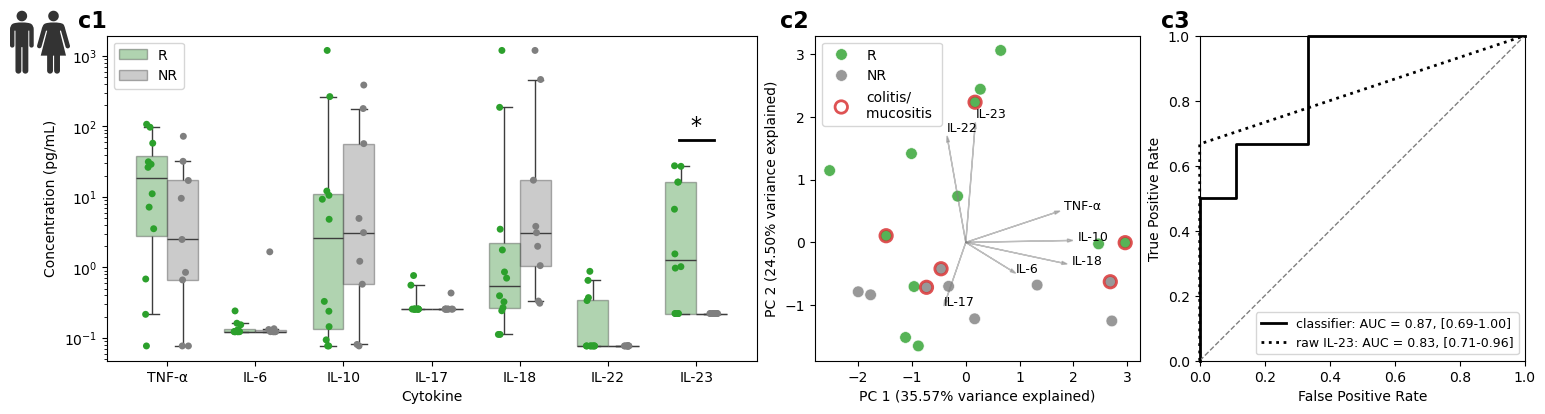

In [62]:
# this plot will copy the style of the ibd combined plot boxplots with points in A, PCA in B and AUROC in C

mosaic = """
AABC
"""
fig, ax_dict = plt.subplot_mosaic(mosaic,figsize=(15, 6), layout='constrained')



ax=ax_dict['A']

#convert preici_df from wide to long format
long_df = pd.melt(preici_df, id_vars=['patient_id', 'group'], var_name='cytokine', value_name='conc')   
# Create a boxplot with seaborn and * annotation for p-value
sns.boxplot(data=long_df, x='cytokine', y='conc', hue='group', ax=ax,
            palette=['tab:green', 'tab:gray'], hue_order=['R', 'NR'], width=.7,showfliers=False, zorder=1, boxprops=dict(alpha=.4),whis=[5, 95], order=['tnfa','il6', 'il10', 'il17', 'il18','il22', 'il23'])
sns.stripplot(data=long_df, x='cytokine', y='conc', hue='group', ax=ax,
              palette=["tab:green", "tab:gray"], hue_order=['R', 'NR'],
              dodge=True, jitter=True, alpha=1, zorder=2, order=['tnfa','il6', 'il10', 'il17', 'il18','il22', 'il23'])

ax.legend_.remove()
# Get existing legend and add significance legend
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[0:2] , labels[0:2], loc='upper left')

# Add p-value annotations
y_max = long_df['conc'].max()
y_min = long_df['conc'].min()
y_range = (y_max - y_min)/10
for i, cytokine in enumerate([ 'tnfa','il6', 'il10', 'il17', 'il18','il22', 'il23' ]):
    p_value = corrected_results[cytokine]
    if p_value < 0.001:
        annotation = '***'
    elif p_value < 0.01:
        annotation = '**'
    elif p_value < 0.05:
        annotation = '*'
    else:
        annotation = 'ns'
    
    if annotation != 'ns':
        # Determine y position for annotation
        y, h, col = long_df[long_df['cytokine'] == cytokine]['conc'].max() + y_range*0.3, y_range*0.05, 'k'
        ax.plot([i - 0.2, i + 0.2], [y, y], lw=2, c=col)
        ax.text(i, y + h, annotation, ha='center', va='bottom', color=col, fontsize=16)


ax.set_yscale('log')
ax.set_ylabel('Concentration (pg/mL)')
ax.set_xlabel('Cytokine')

# Update x-tick labels with your existing display_names dictionary
current_labels = ax.get_xticklabels()
new_labels = []
for label in current_labels:
    cytokine = label.get_text()
    new_label = display_names.get(cytokine, cytokine)  # Use original if not in dictionary
    new_labels.append(new_label)
ax.set_xticklabels(new_labels)

ax.set_box_aspect(0.5)

ax=ax_dict['B']

# use tab:red and tab:gray for R and NR
custom_palette = {'R': 'tab:green', 'NR': 'tab:gray'}
scatter = sns.scatterplot(ax=ax,x=pca_result[:, 0], y=pca_result[:, 1], 
                         hue=groups, 
                         palette=custom_palette, 
                         #style=groups,
                         s=70,  # Larger markers
                         alpha=0.8,  # Slight transparency
                         edgecolor='white',  # White edges for better contrast
                         linewidth=0.5)


colitis_color= 'tab:red' 
# In the special patients scatter plot:
ax.scatter(pca_result[special_indices, 0], pca_result[special_indices, 1], 
            color='none', s=80, alpha=0.8, edgecolor=colitis_color, linewidth=2, 
            marker='o', label='colitis/\nmucositis ')

ax.set_box_aspect(1)
ax.set_xlabel(f'PC 1 ({pca.explained_variance_ratio_[0]:.2%} variance explained)')
ax.set_ylabel(f'PC 2 ({pca.explained_variance_ratio_[1]:.2%} variance explained)')
#sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))


for i, cytokine in enumerate(features.columns):
    ax.arrow(0, 0, 
              loadings_correlated.T[0, i]*arrow_scale,  # Scale arrows for visibility
              loadings_correlated.T[1, i]*arrow_scale, 
              color='gray', alpha=0.5, head_width=0.05, head_length=0.1, lw=1)
    ax.text(loadings_correlated.T[0, i]*text_scale, 
             loadings_correlated.T[1, i]*text_scale, 
             display_names[cytokine], color='black', fontsize=9)


ax.legend_.remove()
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[0:3] , labels[0:3], loc='upper left')

ax=ax_dict['C']

ax.plot(fpr_model, tpr_model, color='black', linestyle='-',lw=2, label=f'classifier: AUC = {auc_score_model:.2f}, [{full_model_[1][0]:.2f}-{full_model_[1][1]:.2f}]')
ax.plot(fpr_il23, tpr_il23, color='black', linestyle=':', lw=2, label=f'raw IL-23: AUC = {auc_score_il23:.2f}, [{raw_[1][0]:.2f}-{raw_[1][1]:.2f}]')
ax.set_box_aspect(1)
for artist in ax.get_children():
    artist.set_clip_on(False)

ax.plot([0, 1], [0, 1],"--", color='gray', lw=1)
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.0])
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_box_aspect(1.0)
ax.legend(fontsize=9, loc='lower right')


#add a,b,c labels to subplots
ax=ax_dict['A']
ax.text(0, 1.08, 'c1', transform=ax.transAxes,
            fontsize=16, fontweight='bold', va='top', ha='right')
ax=ax_dict['B']
ax.text(-0.02, 1.08, 'c2', transform=ax.transAxes,
            fontsize=16, fontweight='bold', va='top', ha='right')
ax=ax_dict['C']
ax.text(-0.03, 1.08, 'c3', transform=ax.transAxes,
            fontsize=16, fontweight='bold', va='top', ha='right')


ax=fig.add_axes([0 ,0.4, 0.2, .2]) # [left, bottom, width, height] in figure coordinates
ax.axis('off')
place_svg_on_ax(ax, human_svg_path, 0.0, 1.8, .2)


fig.savefig(figures+'cancer_main_text.pdf', bbox_inches='tight', format='pdf', dpi=300, transparent=True)
plt.show()